In [ ]:
import gdown


In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1aQOjCEsjZx1J1MSTYZfvjwbcgobIWlO7/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1aQOjCEsjZx1J1MSTYZfvjwbcgobIWlO7
From (redirected): https://drive.google.com/uc?id=1aQOjCEsjZx1J1MSTYZfvjwbcgobIWlO7&confirm=t&uuid=d0f84cb7-d335-45a7-8adb-b05c16eca0d1
To: /content/lungcancer.zip
100% 209M/209M [00:05<00:00, 40.3MB/s]


In [ ]:
!unzip lungcancer.zip

Archive:  lungcancer.zip
  inflating: Test cases/000001_03_01_088.png  
  inflating: Test cases/000017_02_01_016.png  
  inflating: Test cases/000019_01_01_021.png  
  inflating: Test cases/000019_02_01_025.png  
  inflating: Test cases/000019_03_01_025.png  
  inflating: Test cases/000020_01_01_066.png  
  inflating: Test cases/000020_02_01_062.png  
  inflating: Test cases/000020_03_01_134.png  
  inflating: Test cases/000020_03_01_166.png  
  inflating: Test cases/000020_03_01_212.png  
  inflating: Test cases/000020_04_01_116.png  
  inflating: Test cases/000020_04_01_143.png  
  inflating: Test cases/000020_04_01_159.png  
  inflating: Test cases/000021_01_01_016.png  
  inflating: Test cases/000021_02_01_068.png  
  inflating: Test cases/000021_03_01_012.png  
  inflating: Test cases/000021_03_01_017.png  
  inflating: Test cases/000021_04_01_090.png  
  inflating: Test cases/000027_01_01_113.png  
  inflating: Test cases/000027_02_01_105.png  
  inflating: Test cases/000027_03_0

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

In [ ]:
# prompt: use splitsfolders to split /content/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset into train test val

import splitfolders

splitfolders.ratio('/content/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset', output="output", seed=1337, ratio=(.8, 0.1,0.1))


Copying files: 1097 files [00:01, 879.41 files/s]


In [ ]:
import tensorflow as tf
import tensorflow.keras

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
traingen = ImageDataGenerator(1.0/255)
train=traingen.flow_from_directory('/content/output/train',target_size=(224,224),batch_size=32)

Found 876 images belonging to 3 classes.


In [ ]:
testgen = ImageDataGenerator(1.0/255)
test=testgen.flow_from_directory('/content/output/test',target_size=(224,224),batch_size=32)

Found 112 images belonging to 3 classes.


In [ ]:
valgen = ImageDataGenerator(1.0/255)
val=valgen.flow_from_directory('/content/output/val',target_size=(224,224),batch_size=32)

Found 109 images belonging to 3 classes.


In [ ]:
images, labels = next(train)

/usr/local/lib/python3.10/dist-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


In [ ]:
train.image_shape

(224, 224, 3)

In [ ]:
images[0].shape

(224, 224, 3)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

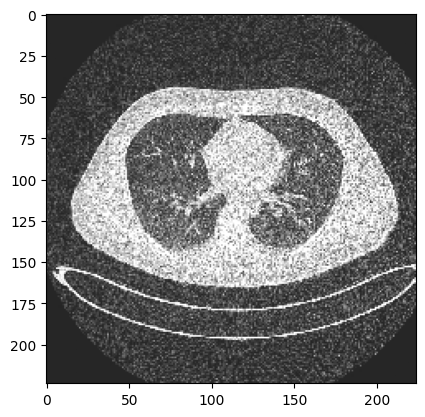

In [ ]:
plt.imshow(images[0]/255)
plt.show()

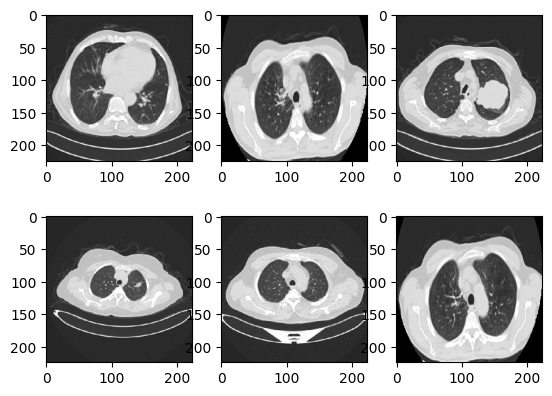

<Figure size 1000x1100 with 0 Axes>

In [ ]:
for i in range(1, 7):
  plt.subplot(2, 3, i)
  plt.imshow(images[i] / 255)
plt.figure(figsize=(10,11))
plt.show()

In [ ]:
import numpy as np
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Constants for LBP
RADIUS = 1
N_POINTS = 8 * RADIUS

# Define a function to extract GLCM features
def extract_glcm_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
    features = [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'dissimilarity')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ]
    return np.array(features)

# Define a function to extract LBP features
def extract_lbp_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, N_POINTS, RADIUS, method='uniform')
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, N_POINTS + 3), range=(0, N_POINTS + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)  # Normalize histogram
    return hist





In [ ]:
from skimage.feature import hog
from skimage.filters import gabor
from skimage.color import rgb2gray

# HOG Feature Extraction
def extract_hog_features(image):
    gray_image = rgb2gray(image)
    hog_features, _ = hog(gray_image, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
    return hog_features

# Gabor Feature Extraction
def extract_gabor_features(image):
    gray_image = rgb2gray(image)
    gabor_features = []
    frequencies = [0.1, 0.2, 0.3, 0.4]  # Example frequencies to try for Gabor filters
    for theta in range(4):  # Use 4 orientations for Gabor filter
        theta = theta / 4. * np.pi
        for frequency in frequencies:
            real, imag = gabor(gray_image, frequency=frequency, theta=theta)
            gabor_features.append(real.mean())  # Mean of the real part of the Gabor response
            gabor_features.append(real.var())   # Variance of the real part
    return np.array(gabor_features)


In [ ]:
def extract_combined_features(image):
    # GLCM and LBP features
    glcm_features = extract_glcm_features(image)
    lbp_features = extract_lbp_features(image)

    # HOG and Gabor features
    hog_features = extract_hog_features(image)
    gabor_features = extract_gabor_features(image)

    # Combine all features into a single feature vector
    combined_features = np.concatenate([glcm_features, lbp_features, hog_features, gabor_features])
    return combined_features


In [ ]:
# Extract features for training, validation, and test sets
train_features = []
train_labels = []

for batch, labels in train:
    for img, label in zip(batch, labels):
        img_array = np.array(img * 255, dtype=np.uint8)  # Scale back to [0, 255]
        features = extract_combined_features(img_array)
        train_features.append(features)
        train_labels.append(np.argmax(label))  # Convert categorical to single integer

    if len(train_features) >= train.samples:
        break

train_features = np.array(train_features)
train_labels = np.array(train_labels)


val_features = []
val_labels = []

for batch, labels in val:
    for img, label in zip(batch, labels):
        img_array = np.array(img * 255, dtype=np.uint8)
        features = extract_combined_features(img_array)
        val_features.append(features)
        val_labels.append(np.argmax(label))

    if len(val_features) >= val.samples:
        break

val_features = np.array(val_features)
val_labels = np.array(val_labels)


test_features = []
test_labels = []

for batch, labels in test:
    for img, label in zip(batch, labels):
        img_array = np.array(img * 255, dtype=np.uint8)
        features = extract_combined_features(img_array)
        test_features.append(features)
        test_labels.append(np.argmax(label))

    if len(test_features) >= test.samples:
        break

test_features = np.array(test_features)
test_labels = np.array(test_labels)


/usr/local/lib/python3.10/dist-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


In [ ]:
np.save('train_features.npy', train_features)
np.save('train_labels.npy', train_labels)
np.save('val_features.npy', val_features)
np.save('val_labels.npy', val_labels)
np.save('test_features.npy', test_features)
np.save('test_labels.npy', test_labels)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


scaler = StandardScaler()
train_features_pca=scaler.fit_transform(train_features)
val_features_pca=scaler.transform(val_features)
test_features_pca=scaler.transform(test_features)

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
import numpy as np

hyperparameter_space = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

best_accuracy = 0
best_params = {}

episodes = 5

for episode in range(episodes):

    C = np.random.choice(hyperparameter_space['C'])
    kernel = np.random.choice(hyperparameter_space['kernel'])

    # Train One-vs-Rest SVM classifier with selected hyperparameters
    clf = OneVsRestClassifier(SVC(kernel=kernel, C=C, random_state=42))

    # Use cross-validation with shuffling to get a better accuracy estimate and reduce overfitting
    scores = cross_val_score(clf, train_features, train_labels, cv=5)  # 5-fold CV
    accuracy = scores.mean()

    # Update the best parameters if current accuracy is the highest
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = {'C': C, 'kernel': kernel}

    print(f"Episode {episode + 1}/{episodes} - C: {C}, Kernel: {kernel}, Accuracy: {accuracy:.4f}")

print("\nBest Hyperparameters found through simplified tuning:")
print("C:", best_params['C'])
print("Kernel:", best_params['kernel'])
print("Validation Accuracy with Best Hyperparameters:", best_accuracy)


Episode 1/5 - C: 1.0, Kernel: linear, Accuracy: 0.9909
Episode 2/5 - C: 1.0, Kernel: rbf, Accuracy: 0.5731
Episode 3/5 - C: 1.0, Kernel: linear, Accuracy: 0.9909
Episode 4/5 - C: 1.0, Kernel: linear, Accuracy: 0.9909
Episode 5/5 - C: 0.1, Kernel: linear, Accuracy: 0.9909

Best Hyperparameters found through simplified tuning:
C: 1.0
Kernel: linear
Validation Accuracy with Best Hyperparameters: 0.9908701298701299


In [ ]:
clf_best = OneVsRestClassifier(SVC(kernel=best_params['kernel'], C=best_params['C'], random_state=42))
clf_best.fit(train_features, train_labels)

OneVsRestClassifier(estimator=SVC(kernel='linear', random_state=42))

In [ ]:
val_predictions = clf_best.predict(val_features)
print("\nFinal Validation Accuracy:", accuracy_score(val_labels, val_predictions))
print("Validation Classification Report:\n", classification_report(val_labels, val_predictions))

# Test Performance
test_predictions = clf_best.predict(test_features)
print("Test Accuracy:", accuracy_score(test_labels, test_predictions))
print("Test Classification Report:\n", classification_report(test_labels, test_predictions))


Final Validation Accuracy: 1.0
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        41

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109

Test Accuracy: 0.9821428571428571
Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.98      1.00      0.99        57
           2       0.98      0.98      0.98        43

    accuracy                           0.98       112
   macro avg       0.99      0.96      0.97       112
weighted avg       0.98      0.98      0.98       112



<Axes: title={'center': 'Test Confusion_matrix'}>

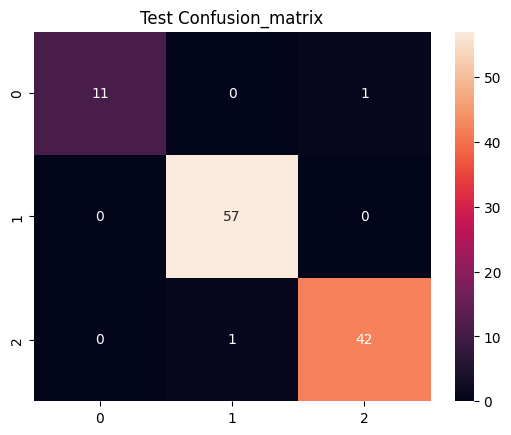

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import confusion_matrix
plt.title('Test Confusion_matrix')
sb.heatmap(confusion_matrix(test_labels,test_predictions),annot=True)

<Axes: title={'center': 'Validation Confusion_matrix'}>

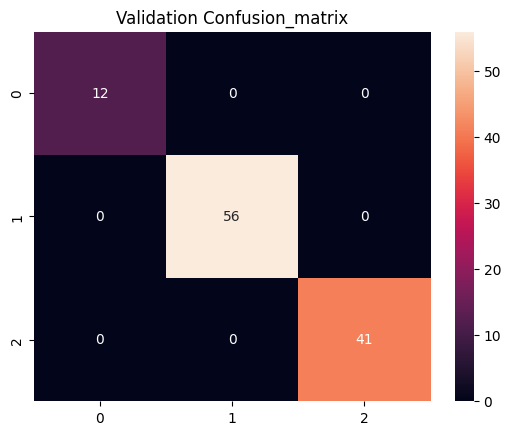

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import confusion_matrix
plt.title('Validation Confusion_matrix')
sb.heatmap(confusion_matrix(val_labels, val_predictions),annot=True)